# Solution: Challenge Week 06

## Libraries and settings

In [13]:
# Libraries
import re
import io
import sys
import os
import textwrap
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from dotenv import load_dotenv

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load OpenAI API key from the root .env file
def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'requirements.txt').exists() or (parent / '.git').exists():
            return parent
    return start

_repo_root = _find_repo_root(Path.cwd())
load_dotenv(_repo_root / '.env')

api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise ValueError(
        "Missing OPENAI_API_KEY. Create a top-level .env file in the repository root "
        "and set OPENAI_API_KEY=..."
    )

client = OpenAI(api_key=api_key)

# Show current working directory
print(os.getcwd())

u:\Lektionen\GitHub_Repositories\scientific_programming\Week_06\challenge


## Import smartphone data

In [14]:
# Read the data
df_orig = pd.read_csv('./data/smartphone_data.csv', sep=';')

# Show the number of rows and columns
print(df_orig.shape)

# Print the first 10 rows
df_orig.iloc[:10,]

(5000, 12)


,offer_id,dealer_plz,dealer_city,dealer_street_house_nr,make,model,price_raw,camera_resolution_raw,battery_life_raw,storage_size_raw,screen_size_raw,description_raw
0,83197857,6394,Volketswil,Blaserstrasse 19,Apple,iPhone 13,CHF 2518.-,20 MP,16 hrs,256 GB,6.1 IN,"Langlebige Batterie mit Schnellladefunktion, d..."
1,36687537,9532,Oberwil,Furrerstrasse 1,Vivo,Vivo V21,CHF 266.-,12 MP,16 hrs,128 GB,5.8 IN,Modernste Gesichtserkennungstechnologie für Si...
2,66722344,2227,Rüti,Maierstrasse 31,Vivo,Vivo V21,CHF 424.-,12 MP,20 hrs,256 GB,5.8 IN,Ultra-HD-Display für eine atemberaubende Bildq...
3,56164955,5766,Bülach,Sidlerstrasse 6,Google,Pixel 6a,CHF 597.-,12 MP,25 hrs,64 GB,5.8 IN,Mit Stiftunterstützung für Kreativität und Prä...
4,94374605,8304,Belp,Steinerstrasse 8,Google,Pixel 6,CHF 1934.-,20 MP,23 hrs,64 GB,5.8 IN,Aufgeteilt in benutzerfreundliche Kategorien f...
5,20709497,3292,Wohlen,Walderstrasse 15,Google,Pixel 8,CHF 743.-,12 MP,20 hrs,64 GB,5.8 IN,Elegantes Gehäuse aus kratzfestem Glas und rob...
6,99949389,6224,Ecublens,Hodelstrasse 49,Apple,iPhone 16,CHF 572.-,12 MP,22 hrs,64 GB,5.8 IN,Professionelle Bildbearbeitung direkt auf dem ...
7,95899313,2562,Le Grand-Saconnex,Grafstrasse 77,Apple,iPhone SE,CHF 1284.-,16 MP,21 hrs,64 GB,5.8 IN,Lässt sich einfach mit anderen Smart-Home-Gerä...
8,52339391,3611,Wettingen,Kaiserstrasse 70,Vivo,Vivo X60,CHF 483.-,16 MP,25 hrs,64 GB,5.8 IN,Verbesserte Bildstabilisierung für perfekte Vi...
9,63100814,7550,Herisau,Hoferstrasse 173,Google,Pixel 6,CHF 269.-,12 MP,35 hrs,128 GB,6.1 IN,Optimaler Komfort für lange Streaming-Sessions...


## Show data types

In [15]:
# Show data types
print(df_orig.dtypes)

offer_id                   int64
dealer_plz                 int64
dealer_city               object
dealer_street_house_nr    object
make                      object
model                     object
price_raw                 object
camera_resolution_raw     object
battery_life_raw          object
storage_size_raw          object
screen_size_raw           object
description_raw           object
dtype: object


## Count and remove missing values

In [16]:
# Count missing values
print('Count missing values')
print(df_orig.isna().sum())

# Remove missing values
print('\nCheck whether missing values were successfully removed')
df_clean_01 = df_orig.dropna()
df_clean_01.isna().sum()

Count missing values
offer_id                  0
dealer_plz                0
dealer_city               0
dealer_street_house_nr    0
make                      0
model                     0
price_raw                 0
camera_resolution_raw     0
battery_life_raw          0
storage_size_raw          0
screen_size_raw           0
description_raw           0
dtype: int64

Check whether missing values were successfully removed


offer_id                  0
dealer_plz                0
dealer_city               0
dealer_street_house_nr    0
make                      0
model                     0
price_raw                 0
camera_resolution_raw     0
battery_life_raw          0
storage_size_raw          0
screen_size_raw           0
description_raw           0
dtype: int64

## Count and remove duplicated values

In [17]:
# Count duplicated values
print('Count duplicated values')
print(df_clean_01.duplicated().sum())

# Remove duplicated values
print('\nCheck whether duplicated values were successfully removed')
df = df_clean_01.drop_duplicates()
print(df.duplicated().sum())

Count duplicated values
0

Check whether duplicated values were successfully removed
0


## Define functions for LLM-based code generation and execution

In [18]:
# Function to query GPT for Python code
def query_gpt(context, question, model='gpt-4o-mini'):
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a coding assistant. Provide only Python code based on user queries. Do not include any Markdown formatting or explanations outside the code block."},
                {"role": "user", "content": f"Context: {context}\n\nQuestion: {question}\n\nAlso, provide a short explanation of the result after the code block under the label 'Explanation:'."},
            ],
            temperature=0,
            max_tokens=1500,
        )
        full_response = response.choices[0].message.content

        # Extract code block using regular expression
        code_match = re.search(r'```python(.*?)```', full_response, re.DOTALL)
        if code_match:
            code = code_match.group(1).strip()
            explanation = full_response.split('Explanation:')[1].strip() if 'Explanation:' in full_response else 'No explanation provided.'
            return code, explanation
        else:
            return 'No code block found in the response.', 'No explanation provided.'
    except Exception as e:
        return f'Error querying GPT: {e}', 'No explanation provided.'


# Function to execute Python code dynamically and capture the output
def execute_python_code(code, data=None):
    local_scope = {'plt': plt, 'pd': pd, 're': re}
    if data is not None:
        local_scope['df'] = data
    try:
        # Redirect stdout to capture print statements
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
        exec(code, local_scope)
        output = sys.stdout.getvalue()
        sys.stdout = old_stdout

        # Save the plot if one was created
        if plt.get_fignums():
            plt.savefig('./data/graphic.png', bbox_inches='tight', dpi=150)
            plt.show()
            plt.close()

        return output.strip()
    except Exception as e:
        sys.stdout = old_stdout
        return f'Error executing code: {e}'

## Use LLM to generate code for price extraction

In [19]:
# Context: describe the data to the LLM
context = (
    "import pandas as pd\n"
    "import re\n"
    "df = pd.read_csv('./data/smartphone_data.csv', sep=';')\n"
    f"# Column names: {list(df.columns)}\n"
    f"# Example value of price_raw: '{df['price_raw'].iloc[0]}'\n"
)

# Question for the LLM
question = (
    "Extract the numerical price from the 'price_raw' column (format: 'CHF 2518.-') "
    "using a regular expression and store the result as an integer in a new column "
    "called 'price'. Remove any rows where the price could not be extracted. "
    "Print the data types and show the first 5 rows of df with the new 'price' column."
)

# Query the LLM
generated_code_price, explanation_price = query_gpt(context, question)

# Wrap explanation text
explanation_wrapped = textwrap.fill(explanation_price, width=80)

print('Generated Python code:')
print(generated_code_price)
print('\nExplanation:')
print(explanation_wrapped)

Generated Python code:
import pandas as pd
import re

df = pd.read_csv('./data/smartphone_data.csv', sep=';')

# Extract numerical price using regex
df['price'] = df['price_raw'].str.extract(r'(\d+)').astype(float)

# Remove rows where price could not be extracted
df = df.dropna(subset=['price'])

# Convert price to integer
df['price'] = df['price'].astype(int)

# Print data types and first 5 rows
print(df.dtypes)
print(df.head())

Explanation:
The code extracts the numerical part of the 'price_raw' column, converts it to
an integer, and stores it in a new column called 'price'. Rows where the price
could not be extracted are removed, ensuring that the 'price' column contains
only valid integer values. The data types of the DataFrame are printed along
with the first five rows to verify the changes.


## Execute the generated code for price extraction

In [20]:
# Execute the generated code
output = execute_python_code(generated_code_price, data=df)
if output:
    print(output)

# Extract price column back into df for subsequent steps
df['price'] = df['price_raw'].str.extract(r'(\d+)').astype(int)
df = df.dropna(subset=['price'])

print('\nPrice column dtype:', df['price'].dtype)
print('Rows after extraction:', len(df))

offer_id                   int64
dealer_plz                 int64
dealer_city               object
dealer_street_house_nr    object
make                      object
model                     object
price_raw                 object
camera_resolution_raw     object
battery_life_raw          object
storage_size_raw          object
screen_size_raw           object
description_raw           object
price                      int32
dtype: object
   offer_id  dealer_plz dealer_city dealer_street_house_nr    make      model  \
0  83197857        6394  Volketswil       Blaserstrasse 19   Apple  iPhone 13   
1  36687537        9532     Oberwil        Furrerstrasse 1    Vivo   Vivo V21   
2  66722344        2227        Rüti        Maierstrasse 31    Vivo   Vivo V21   
3  56164955        5766      Bülach        Sidlerstrasse 6  Google   Pixel 6a   
4  94374605        8304        Belp       Steinerstrasse 8  Google    Pixel 6   

    price_raw camera_resolution_raw battery_life_raw storage_size_raw 

## Use LLM to generate code for average price per brand (bar chart)

In [25]:
# Context for bar chart
context_chart = (
    "import pandas as pd\n"
    "import matplotlib.pyplot as plt\n"
    "# df has columns: make (brand), price (integer)\n"
    f"# Available brands: {sorted(df['make'].unique().tolist())}\n"
)

# Question for the LLM
question_chart = (
    "Calculate the average price per smartphone brand from the 'make' column and 'price' column "
    "of df. Create a horizontal bar chart (figsize=(6, 4)) showing the average price per brand, "
    "sorted in descending order. Use 'lightseagreen' as bar color. Add a title 'Average Smartphone Price per Brand', "
    "x-axis label 'Average Price (CHF)', and a light grid on the x-axis."
)

# Query the LLM
generated_code_chart, explanation_chart = query_gpt(context_chart, question_chart)

# Wrap explanation text
explanation_chart_wrapped = textwrap.fill(explanation_chart, width=80)

print('Generated Python code:')
print(generated_code_chart)
print('\nExplanation:')
print(explanation_chart_wrapped)

Generated Python code:
average_price = df.groupby('make')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
average_price.plot(kind='barh', color='lightseagreen')
plt.title('Average Smartphone Price per Brand')
plt.xlabel('Average Price (CHF)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Explanation:
The horizontal bar chart displays the average prices of smartphones for each
brand, allowing for easy comparison. The brands are sorted in descending order,
highlighting which brand has the highest average price. The light grid on the
x-axis enhances readability.


## Execute the generated code for the bar chart

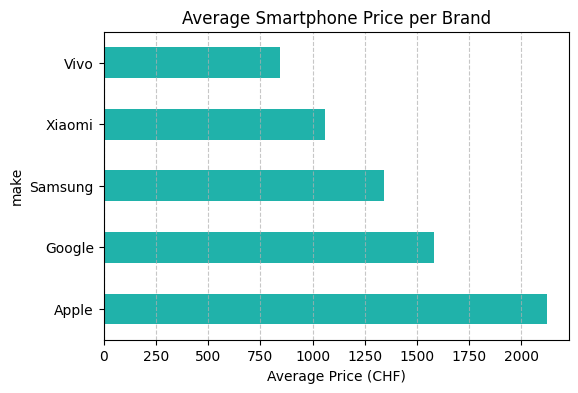

In [26]:
# Execute the generated code
output_chart = execute_python_code(generated_code_chart, data=df)
if output_chart:
    print(output_chart)

## Average price per brand (manual verification)

In [23]:
# Calculate average price per brand
avg_price_per_brand = df.groupby('make')['price'].mean().sort_values(ascending=False)

# Show result
print('Average price per brand (CHF):')
print(avg_price_per_brand.round(2).to_string())

Average price per brand (CHF):
make
Apple      2120.24
Google     1583.31
Samsung    1343.23
Xiaomi     1058.12
Vivo        842.75


### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [24]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
NT
Windows | 10
Datetime: 2026-03-30 14:22:54
Python Version: 3.11.10
-----------------------------------
